LOGISTIC REGRESSION

In [211]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [212]:
#Load Dataset
df = pd.read_csv("german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [213]:
#Data Inspection
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [214]:
#Data Cleaning
df.columns = df.columns.str.strip()

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [215]:
#Handle missing values
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=["number"]).columns:
    df[col] = df[col].fillna(df[col].median())

In [216]:
#Check Target Column
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [217]:
#Encode 
df["Risk"] = df["Risk"].map({"good": 1, "bad": 0})
df["Risk"].value_counts()

Risk
1    700
0    300
Name: count, dtype: int64

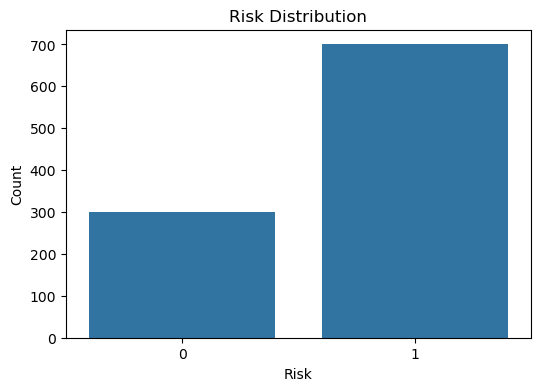

In [218]:
#EDA
#Risk Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Risk", data=df)
plt.title("Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.show()



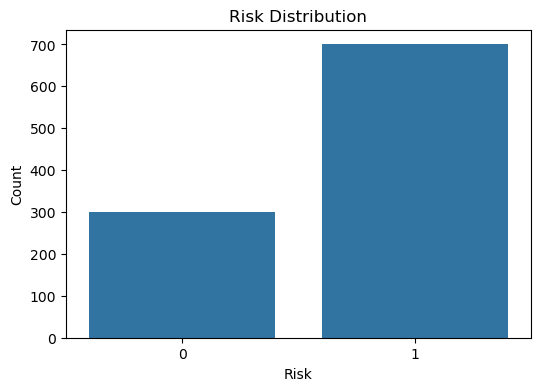

In [219]:
#Age distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Risk", data=df)
plt.title("Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.show()

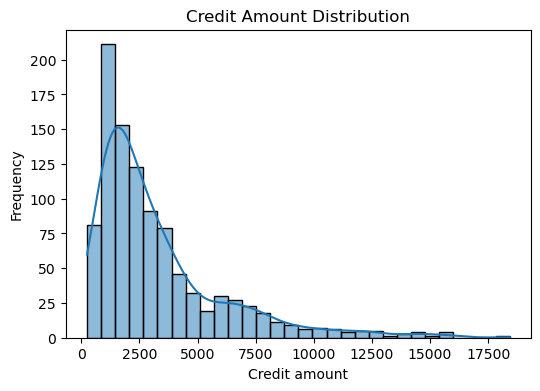

In [220]:
#: EDA — credit amount distribution

plt.figure(figsize=(6,4))
sns.histplot(df["Credit amount"], bins=30, kde=True)
plt.title("Credit Amount Distribution")
plt.xlabel("Credit amount")
plt.ylabel("Frequency")
plt.show()

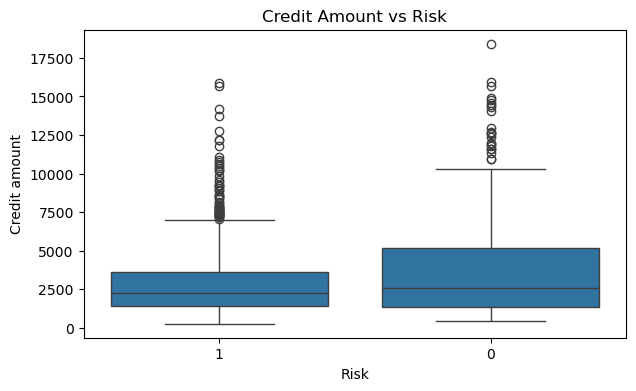

In [221]:
 #EDA credit amount vs risk
df_clean = df.dropna(subset=["Risk", "Credit amount"])  # Remove rows with missing values
df_clean["Risk"] = df_clean["Risk"].astype(str)  # Ensure Risk column is string type
df_clean["Credit amount"] = pd.to_numeric(df_clean["Credit amount"], errors='coerce')  # Convert to numeric
df_clean = df_clean.dropna(subset=["Credit amount"])  # Remove any rows that couldn't be converted to numeric

plt.figure(figsize=(7,4))
sns.boxplot(x="Risk", y="Credit amount", data=df_clean)  # Use cleaned dataframe
plt.title("Credit Amount vs Risk")
plt.xlabel("Risk")
plt.ylabel("Credit amount")
plt.show()





In [222]:
#Split Features and Target
X = df.drop("Risk", axis=1)
y = df["Risk"]

X.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,little,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,little,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [223]:
#Encode Features
X = pd.get_dummies(X, drop_first=True)
X.head()

,Unnamed: 0,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,0,67,2,1169,6,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False
1,1,22,2,5951,48,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False
2,2,49,1,2096,12,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False
3,3,45,2,7882,42,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,4,53,2,4870,24,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [224]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [225]:
#Scaling Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [232]:
#Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [233]:
#Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [234]:
#Evaluate Logistic Regression
lr_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression")
print("Accuracy:", lr_acc)
print("Precision:", lr_prec)
print("Recall:", lr_rec)
print("F1 Score:", lr_f1)
print(classification_report(y_test, lr_pred))



Logistic Regression
Accuracy: 0.71
Precision: 0.7383720930232558
Recall: 0.9071428571428571
F1 Score: 0.8141025641025641
              precision    recall  f1-score   support

           0       0.54      0.25      0.34        60
           1       0.74      0.91      0.81       140

    accuracy                           0.71       200
   macro avg       0.64      0.58      0.58       200
weighted avg       0.68      0.71      0.67       200



In [235]:
#Evaluate Random Forest
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest")
print("Accuracy:", rf_acc)
print("Precision:", rf_prec)
print("Recall:", rf_rec)
print("F1 Score:", rf_f1)
print(classification_report(y_test, rf_pred))

Random Forest
Accuracy: 0.695
Precision: 0.7365269461077845
Recall: 0.8785714285714286
F1 Score: 0.8013029315960912
              precision    recall  f1-score   support

           0       0.48      0.27      0.34        60
           1       0.74      0.88      0.80       140

    accuracy                           0.69       200
   macro avg       0.61      0.57      0.57       200
weighted avg       0.66      0.69      0.66       200



In [236]:
#Comparison Table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_acc, rf_acc],
    "Precision": [lr_prec, rf_prec],
    "Recall": [lr_rec, rf_rec],
    "F1 Score": [lr_f1, rf_f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.710,0.738372,0.907143,0.814103
1,Random Forest,0.695,0.736527,0.878571,0.801303


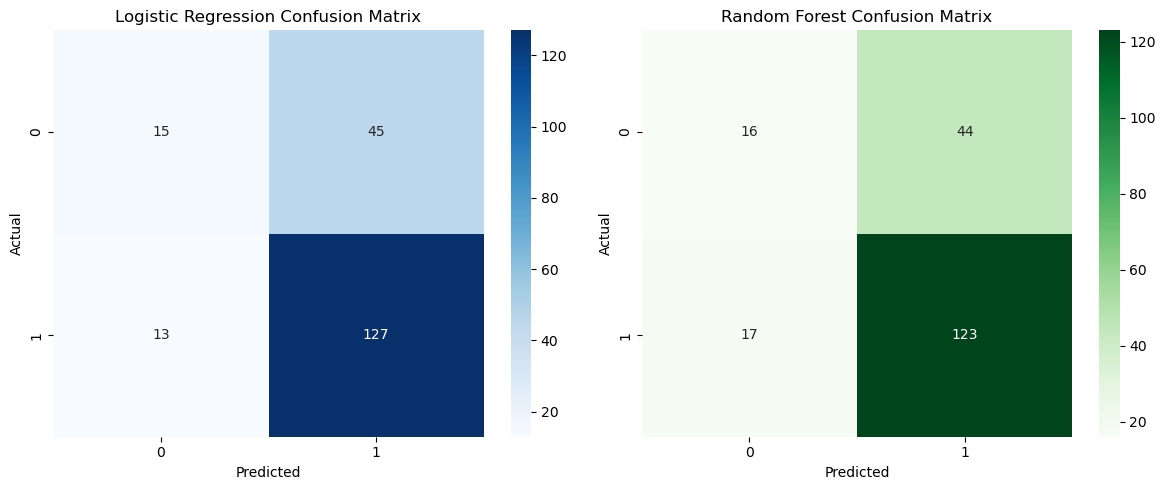

In [237]:
#Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Random Forest Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [238]:
#Recommendation
best_model = results.sort_values(by="F1 Score", ascending=False).iloc[0]
best_model

Model        Logistic Regression
Accuracy                    0.71
Precision               0.738372
Recall                  0.907143
F1 Score                0.814103
Name: 0, dtype: object

Recommendation
The better model is the one with the highest overall performance, especially F1 Score, because it balances precision and recall. Logistic regression  gives the best trade-off for credit risk prediction.